In [15]:
import pandas as pd
pd.reset_option("display.max_rows",None)
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [16]:
df = pd.read_csv("supermarket_sales - Sheet1.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [19]:
data = df[['Unit price','Quantity','Total','gross income']]
data.head()

,Unit price,Quantity,Total,gross income
0,74.69,7,548.9715,26.1415
1,15.28,5,80.2200,3.8200
2,46.33,7,340.5255,16.2155
3,58.22,8,489.0480,23.2880
4,86.31,7,634.3785,30.2085


In [43]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)
print(scaled_data)

[[ 0.71816014  0.5099302   0.91960685  0.91960685]
 [-1.52530319 -0.17453987 -0.98772956 -0.98772956]
 [-0.35278112  0.5099302   0.07144605  0.07144605]
 ...
 [-0.89995809 -1.54348001 -1.17810859 -1.17810859]
 [ 0.38320778 -1.54348001 -1.03293176 -1.03293176]
 [ 1.23361671  0.5099302   1.32783657  1.32783657]]


In [63]:
k = 5
knn = NearestNeighbors(n_neighbors= k)
knn = knn.fit(scaled_data) #Now knn knows data but no computation started

In [64]:
import numpy as np

In [92]:
distances = knn.kneighbors(scaled_data)[0]

outlier_score  = np.mean(distances,axis=1)

threshold = np.percentile(outlier_score,95)
outliers = outlier_score > threshold

df['knn_score'] = outlier_score
df['knn_outliers'] = outliers.astype(int)

print(f"Threshold: {threshold}")
print(f"Outlier count : {np.sum(outliers)}")
df[df['knn_outliers'] == 1][['Unit price','Quantity','Total','gross income']]

Threshold: 0.09921081902830789
Outlier count : 50


,Unit price,Quantity,Total,gross income
32,83.78,8,703.7520,33.5120
37,60.88,9,575.3160,27.3960
38,54.92,8,461.3280,21.9680
59,30.61,6,192.8430,9.1830
93,64.36,9,608.2020,28.9620
107,62.13,6,391.4190,18.6390
114,80.79,9,763.4655,36.3555
118,10.96,10,115.0800,5.4800
127,31.73,9,299.8485,14.2785
128,68.54,8,575.7360,27.4160


In [93]:
import matplotlib.pyplot as plt

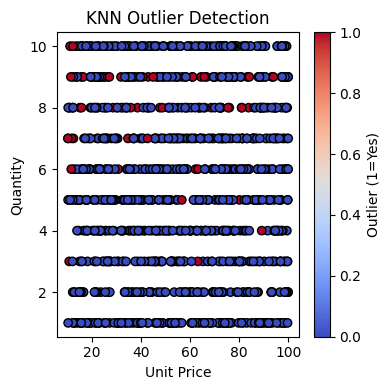

In [94]:
plt.figure(figsize=(4,4))
plt.scatter(df['Unit price'],df['Quantity'],c=df['knn_outliers'], cmap='coolwarm',edgecolors='k')
plt.xlabel('Unit Price')
plt.ylabel('Quantity')
plt.xticks(rotation=0)
plt.title('KNN Outlier Detection')
plt.colorbar(label='Outlier (1=Yes)')
plt.tight_layout()
plt.show()


In [106]:
from sklearn.neighbors import LocalOutlierFactor

In [111]:
lof = LocalOutlierFactor(n_neighbors=20,contamination=0.05)

In [116]:
labels = lof.fit_predict(scaled_data) #-1 -> outlier and 1=> normal

scores = lof.negative_outlier_factor_

outliers1 = labels == -1
df['lof_outliers'] = outliers1.astype(int)
df['lof_scores'] = scores
print(f"Outliers count :{outliers1.sum()} ")


Outliers count :50 


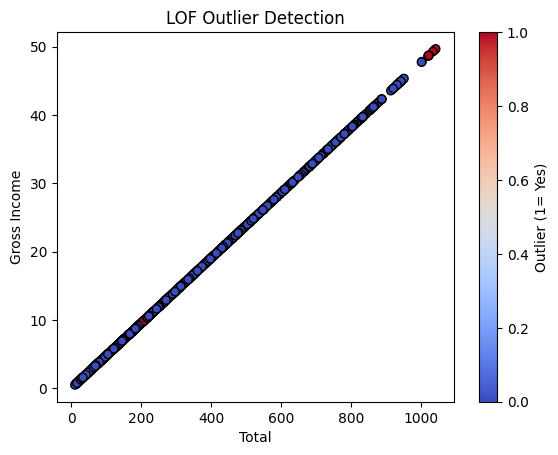

In [127]:
plt.scatter(df['Total'],df['gross income'],c= df['lof_ouliers'], cmap='coolwarm', edgecolors='k')
plt.xlabel('Total')
plt.ylabel('Gross Income')
plt.title('LOF Outlier Detection')
plt.colorbar(label='Outlier (1= Yes)')
plt.xticks(rotation = 0)
plt.show()